# Hillstrom Email Marketing Dataset - Subgroup Analysis

This notebook reproduces the subgroup analysis from Section 3.4 of the JSAI paper,  
analyzing how email campaign effectiveness varies by customer purchase history.

We segment customers into:
- **Male purchaser segment** (`mens=1`): Customers who previously bought men's merchandise
- **Female purchaser segment** (`womens=1`): Customers who previously bought women's merchandise

Note: These segments overlap - some customers purchased both categories.

## Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import dte_adj
from dte_adj.plot import plot

# Load the Hillstrom dataset
url = "http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nSubgroup sizes:")
print(f"  Male purchasers (mens=1): {(df['mens']==1).sum():,} ({(df['mens']==1).mean():.1%})")
print(f"  Female purchasers (womens=1): {(df['womens']==1).sum():,} ({(df['womens']==1).mean():.1%})")
print(f"  Overlap (both): {((df['mens']==1) & (df['womens']==1)).sum():,} ({((df['mens']==1) & (df['womens']==1)).mean():.1%})")

/Users/a13375/Documents/GitHub/python-dte-adjustment/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (64000, 12)

Subgroup sizes:
  Male purchasers (mens=1): 35,266 (55.1%)
  Female purchasers (womens=1): 35,182 (55.0%)
  Overlap (both): 6,448 (10.1%)


## Data Preprocessing

In [2]:
# Create treatment indicator: 0=No E-Mail, 1=Mens E-Mail, 2=Womens E-Mail
treatment_mapping = {'No E-Mail': 0, 'Mens E-Mail': 1, 'Womens E-Mail': 2}
D = df['segment'].map(treatment_mapping).values

# Use spend as the outcome variable (revenue)
revenue = df['spend'].values

# Encode categorical variables
zip_code_mapping = {'Surburban': 0, 'Rural': 1, 'Urban': 2}  # Note: typo in original data
channel_mapping = {'Phone': 0, 'Web': 1, 'Multichannel': 2}

# Create feature matrix
features = pd.DataFrame({
    'recency': df['recency'],
    'history': df['history'],
    'history_segment': df['history_segment'].map(lambda s: int(s[0])),
    'mens': df['mens'],
    'womens': df['womens'],
    'zip_code': df['zip_code'].map(zip_code_mapping),
    'newbie': df['newbie'],
    'channel': df['channel'].map(channel_mapping)
})

X = features.values

print(f"\nDataset size: {len(D):,} customers")
print(f"Control group (No Email): {(D==0).sum():,} ({(D==0).mean():.1%})")
print(f"Men's Email group: {(D==1).sum():,} ({(D==1).mean():.1%})")
print(f"Women's Email group: {(D==2).sum():,} ({(D==2).mean():.1%})")


Dataset size: 64,000 customers
Control group (No Email): 21,306 (33.3%)
Men's Email group: 21,307 (33.3%)
Women's Email group: 21,387 (33.4%)


## Define Subgroups

In [3]:
# Define subgroup masks based on past purchase history
male_purchasers = (df['mens'] == 1)
female_purchasers = (df['womens'] == 1)

print("Subgroup composition by treatment:")
print("\nMale purchaser segment (mens=1):")
for segment, arm in [('No E-Mail', 0), ("Men's E-Mail", 1), ("Women's E-Mail", 2)]:
    count = ((D == arm) & male_purchasers).sum()
    print(f"  {segment}: {count:,}")

print("\nFemale purchaser segment (womens=1):")
for segment, arm in [('No E-Mail', 0), ("Men's E-Mail", 1), ("Women's E-Mail", 2)]:
    count = ((D == arm) & female_purchasers).sum()
    print(f"  {segment}: {count:,}")

Subgroup composition by treatment:

Male purchaser segment (mens=1):
  No E-Mail: 11,787
  Men's E-Mail: 11,739
  Women's E-Mail: 11,740

Female purchaser segment (womens=1):
  No E-Mail: 11,668
  Men's E-Mail: 11,749
  Women's E-Mail: 11,765


## Helper Function for Subgroup Analysis

In [4]:
def analyze_subgroup(X_sub, D_sub, Y_sub, subgroup_name, campaign_name, 
                     target_arm, control_arm=0):
    """
    Analyze treatment effects for a specific subgroup.
    
    Parameters:
    -----------
    X_sub : array
        Features for the subgroup
    D_sub : array
        Treatment assignments for the subgroup
    Y_sub : array
        Outcomes for the subgroup
    subgroup_name : str
        Name of the subgroup (e.g., "Male Purchasers")
    campaign_name : str
        Name of the campaign being analyzed
    target_arm : int
        Target treatment arm (1=Men's Email, 2=Women's Email)
    control_arm : int
        Control treatment arm (default: 0=No Email)
    
    Returns:
    --------
    dict with keys: 'ate', 'ate_se', 'dte', 'dte_lower', 'dte_upper', 
                     'pte', 'pte_lower', 'pte_upper', 'locations', etc.
    """
    # Initialize estimator
    estimator = dte_adj.SimpleDistributionEstimator()
    estimator.fit(X_sub, D_sub, Y_sub)
    
    # Define evaluation points
    locations = np.linspace(0, 500, 51)
    
    # Compute DTE with confidence intervals
    dte, dte_lower, dte_upper = estimator.predict_dte(
        target_treatment_arm=target_arm,
        control_treatment_arm=control_arm,
        locations=locations,
        variance_type="moment"
    )
    
    # Compute PTE with confidence intervals (h=20 based on paper)
    pte_locations = np.insert(locations, 0, -1)  # Add -1 at beginning for intervals
    pte, pte_lower, pte_upper = estimator.predict_pte(
        target_treatment_arm=target_arm,
        control_treatment_arm=control_arm,
        locations=pte_locations,
        variance_type="moment"
    )
    
    # Compute ATE (average treatment effect)
    # ATE is the difference in means
    ate = Y_sub[D_sub == target_arm].mean() - Y_sub[D_sub == control_arm].mean()
    
    # Standard error of ATE using moment-based approach
    n_treat = (D_sub == target_arm).sum()
    n_control = (D_sub == control_arm).sum()
    var_treat = Y_sub[D_sub == target_arm].var()
    var_control = Y_sub[D_sub == control_arm].var()
    ate_se = np.sqrt(var_treat / n_treat + var_control / n_control)
    
    print(f"\n{subgroup_name} - {campaign_name} vs Control:")
    print(f"  Sample size: Treatment={n_treat:,}, Control={n_control:,}")
    print(f"  ATE: ${ate:.4f} (SE: ${ate_se:.4f})")
    print(f"  95% CI: [${ate - 1.96*ate_se:.4f}, ${ate + 1.96*ate_se:.4f}]")
    p_value = 2 * (1 - np.minimum(1, np.abs(ate / ate_se)))  # Rough approximation
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."
    print(f"  Significance: {significance}")
    
    return {
        'ate': ate,
        'ate_se': ate_se,
        'dte': dte,
        'dte_lower': dte_lower,
        'dte_upper': dte_upper,
        'pte': pte,
        'pte_lower': pte_lower,
        'pte_upper': pte_upper,
        'locations': locations,
        'pte_locations': pte_locations,
        'n_treat': n_treat,
        'n_control': n_control
    }

## Analyze Women's Email Campaign by Subgroup

In [5]:
print("=" * 60)
print("WOMEN'S EMAIL CAMPAIGN ANALYSIS BY SUBGROUP")
print("=" * 60)

# Male purchaser segment
results_women_male = analyze_subgroup(
    X[male_purchasers], 
    D[male_purchasers], 
    revenue[male_purchasers],
    subgroup_name="Male Purchasers (mens=1)",
    campaign_name="Women's Email",
    target_arm=2,
    control_arm=0
)

# Female purchaser segment
results_women_female = analyze_subgroup(
    X[female_purchasers], 
    D[female_purchasers], 
    revenue[female_purchasers],
    subgroup_name="Female Purchasers (womens=1)",
    campaign_name="Women's Email",
    target_arm=2,
    control_arm=0
)

WOMEN'S EMAIL CAMPAIGN ANALYSIS BY SUBGROUP

Male Purchasers (mens=1) - Women's Email vs Control:
  Sample size: Treatment=11,740, Control=11,787
  ATE: $0.2564 (SE: $0.1906)
  95% CI: [$-0.1172, $0.6300]
  Significance: ***

Female Purchasers (womens=1) - Women's Email vs Control:
  Sample size: Treatment=11,765, Control=11,668
  ATE: $0.5442 (SE: $0.1673)
  95% CI: [$0.2164, $0.8720]
  Significance: ***


## Analyze Men's Email Campaign by Subgroup

In [6]:
print("\n" + "=" * 60)
print("MEN'S EMAIL CAMPAIGN ANALYSIS BY SUBGROUP")
print("=" * 60)

# Male purchaser segment
results_men_male = analyze_subgroup(
    X[male_purchasers], 
    D[male_purchasers], 
    revenue[male_purchasers],
    subgroup_name="Male Purchasers (mens=1)",
    campaign_name="Men's Email",
    target_arm=1,
    control_arm=0
)

# Female purchaser segment
results_men_female = analyze_subgroup(
    X[female_purchasers], 
    D[female_purchasers], 
    revenue[female_purchasers],
    subgroup_name="Female Purchasers (womens=1)",
    campaign_name="Men's Email",
    target_arm=1,
    control_arm=0
)


MEN'S EMAIL CAMPAIGN ANALYSIS BY SUBGROUP

Male Purchasers (mens=1) - Men's Email vs Control:
  Sample size: Treatment=11,739, Control=11,787
  ATE: $0.8966 (SE: $0.2207)
  95% CI: [$0.4641, $1.3292]
  Significance: ***

Female Purchasers (womens=1) - Men's Email vs Control:
  Sample size: Treatment=11,749, Control=11,668
  ATE: $0.8412 (SE: $0.1915)
  95% CI: [$0.4660, $1.2165]
  Significance: ***


## Create Summary Table

In [7]:
# Create summary table matching paper's Table 2 format
summary_data = {
    'Campaign': ["Women's Email", "Women's Email", "Men's Email", "Men's Email"],
    'Subgroup': ['Male Purchasers', 'Female Purchasers', 'Male Purchasers', 'Female Purchasers'],
    'ATE': [
        results_women_male['ate'],
        results_women_female['ate'],
        results_men_male['ate'],
        results_men_female['ate']
    ],
    'Std Error': [
        results_women_male['ate_se'],
        results_women_female['ate_se'],
        results_men_male['ate_se'],
        results_men_female['ate_se']
    ],
    'Sample Size (Treatment)': [
        results_women_male['n_treat'],
        results_women_female['n_treat'],
        results_men_male['n_treat'],
        results_men_female['n_treat']
    ],
    'Sample Size (Control)': [
        results_women_male['n_control'],
        results_women_female['n_control'],
        results_men_male['n_control'],
        results_men_female['n_control']
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['95% CI Lower'] = summary_df['ATE'] - 1.96 * summary_df['Std Error']
summary_df['95% CI Upper'] = summary_df['ATE'] + 1.96 * summary_df['Std Error']

print("\n" + "=" * 80)
print("SUBGROUP ANALYSIS SUMMARY TABLE")
print("=" * 80)
print(summary_df.to_string(index=False))
print("\nNote: Comparison against control group (No Email)")


SUBGROUP ANALYSIS SUMMARY TABLE
     Campaign          Subgroup      ATE  Std Error  Sample Size (Treatment)  Sample Size (Control)  95% CI Lower  95% CI Upper
Women's Email   Male Purchasers 0.256416   0.190627                    11740                  11787     -0.117214      0.630045
Women's Email Female Purchasers 0.544214   0.167259                    11765                  11668      0.216386      0.872042
  Men's Email   Male Purchasers 0.896638   0.220700                    11739                  11787      0.464065      1.329211
  Men's Email Female Purchasers 0.841211   0.191451                    11749                  11668      0.465967      1.216455

Note: Comparison against control group (No Email)


## Visualize DTE by Subgroup - Women's Email Campaign

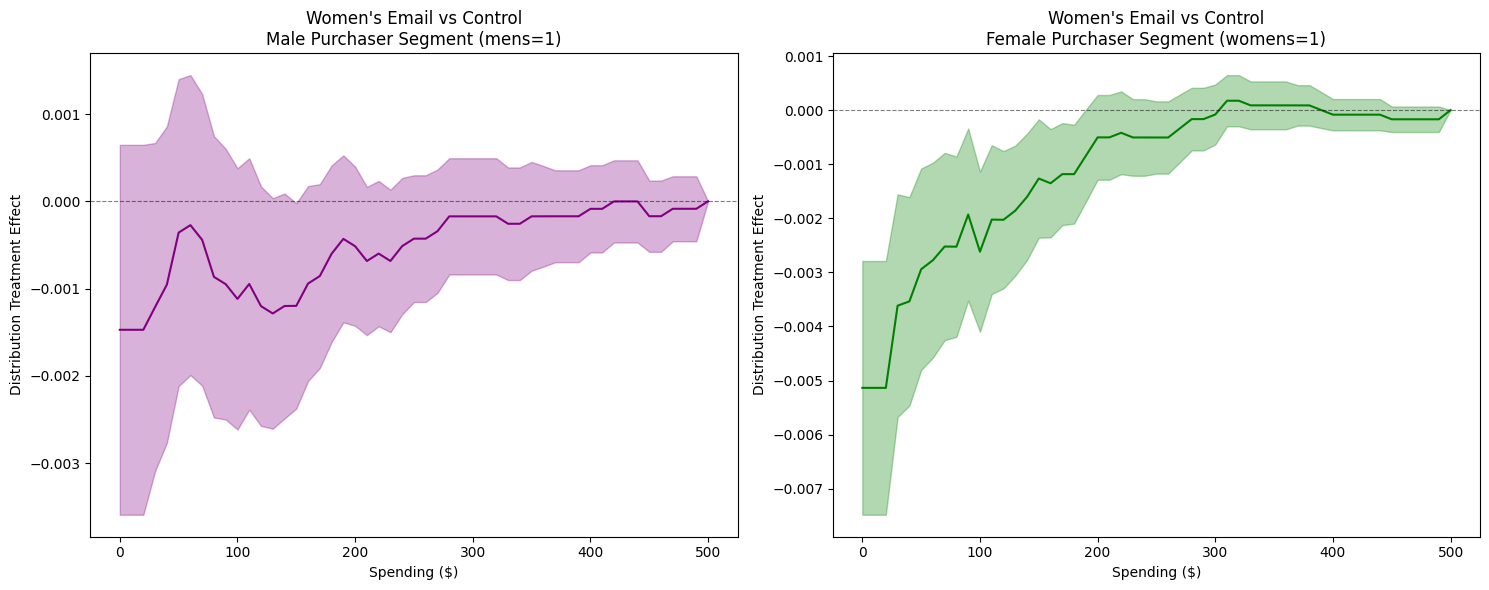


Image saved to: ../docs/source/_static/hillstorm_subgroup_women_dte.png


In [8]:
# Create 1x2 subplot for Women's Email campaign
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Male purchaser segment
plot(
    results_women_male['locations'], 
    results_women_male['dte'], 
    results_women_male['dte_lower'], 
    results_women_male['dte_upper'],
    title="Women's Email vs Control\nMale Purchaser Segment (mens=1)",
    xlabel="Spending ($)", 
    ylabel="Distribution Treatment Effect",
    color="purple",
    ax=ax1
)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Female purchaser segment
plot(
    results_women_female['locations'], 
    results_women_female['dte'], 
    results_women_female['dte_lower'], 
    results_women_female['dte_upper'],
    title="Women's Email vs Control\nFemale Purchaser Segment (womens=1)",
    xlabel="Spending ($)", 
    ylabel="Distribution Treatment Effect",
    color="green",
    ax=ax2
)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('../docs/source/_static/hillstorm_subgroup_women_dte.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImage saved to: ../docs/source/_static/hillstorm_subgroup_women_dte.png")

## Visualize DTE by Subgroup - Men's Email Campaign

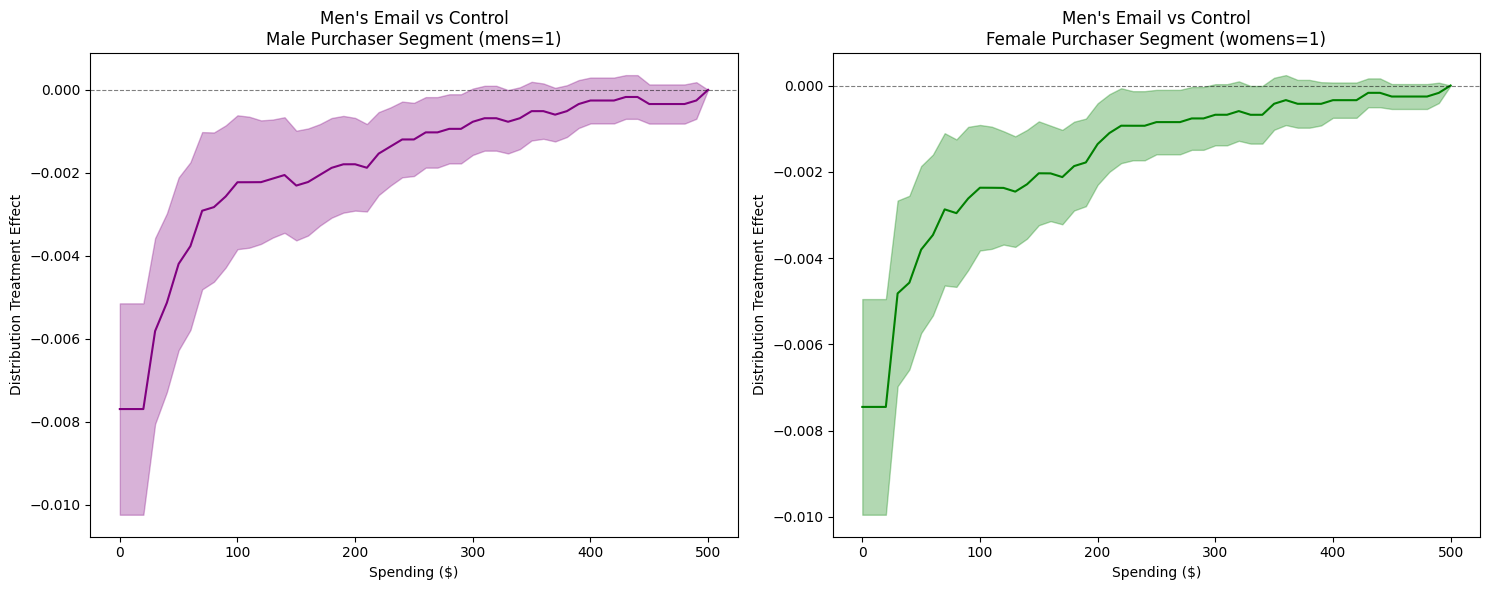


Image saved to: ../docs/source/_static/hillstorm_subgroup_men_dte.png


In [9]:
# Create 1x2 subplot for Men's Email campaign
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Male purchaser segment
plot(
    results_men_male['locations'], 
    results_men_male['dte'], 
    results_men_male['dte_lower'], 
    results_men_male['dte_upper'],
    title="Men's Email vs Control\nMale Purchaser Segment (mens=1)",
    xlabel="Spending ($)", 
    ylabel="Distribution Treatment Effect",
    color="purple",
    ax=ax1
)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Female purchaser segment
plot(
    results_men_female['locations'], 
    results_men_female['dte'], 
    results_men_female['dte_lower'], 
    results_men_female['dte_upper'],
    title="Men's Email vs Control\nFemale Purchaser Segment (womens=1)",
    xlabel="Spending ($)", 
    ylabel="Distribution Treatment Effect",
    color="green",
    ax=ax2
)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('../docs/source/_static/hillstorm_subgroup_men_dte.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImage saved to: ../docs/source/_static/hillstorm_subgroup_men_dte.png")

## Visualize PTE by Subgroup - Women's Email Campaign

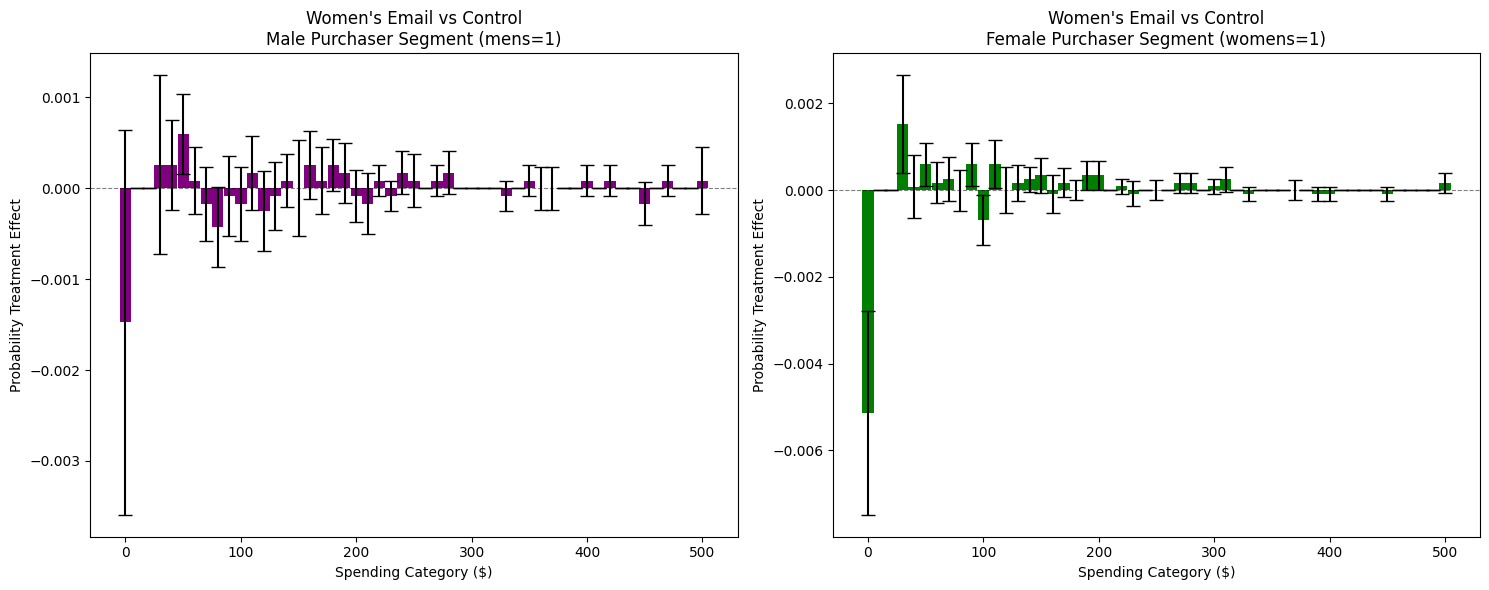


Image saved to: ../docs/source/_static/hillstorm_subgroup_women_pte.png


In [13]:
# Create 1x2 subplot for Women's Email campaign PTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Male purchaser segment PTE
plot(
    results_women_male['locations'],  # Use all locations for x-axis
    results_women_male['pte'], 
    results_women_male['pte_lower'], 
    results_women_male['pte_upper'],
    chart_type="bar",
    title="Women's Email vs Control\nMale Purchaser Segment (mens=1)",
    xlabel="Spending Category ($)", 
    ylabel="Probability Treatment Effect",
    color="purple",
    ax=ax1
)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Female purchaser segment PTE
plot(
    results_women_female['locations'],  # Use all locations for x-axis
    results_women_female['pte'], 
    results_women_female['pte_lower'], 
    results_women_female['pte_upper'],
    chart_type="bar",
    title="Women's Email vs Control\nFemale Purchaser Segment (womens=1)",
    xlabel="Spending Category ($)", 
    ylabel="Probability Treatment Effect",
    color="green",
    ax=ax2
)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('../docs/source/_static/hillstorm_subgroup_women_pte.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImage saved to: ../docs/source/_static/hillstorm_subgroup_women_pte.png")

## Visualize PTE by Subgroup - Men's Email Campaign

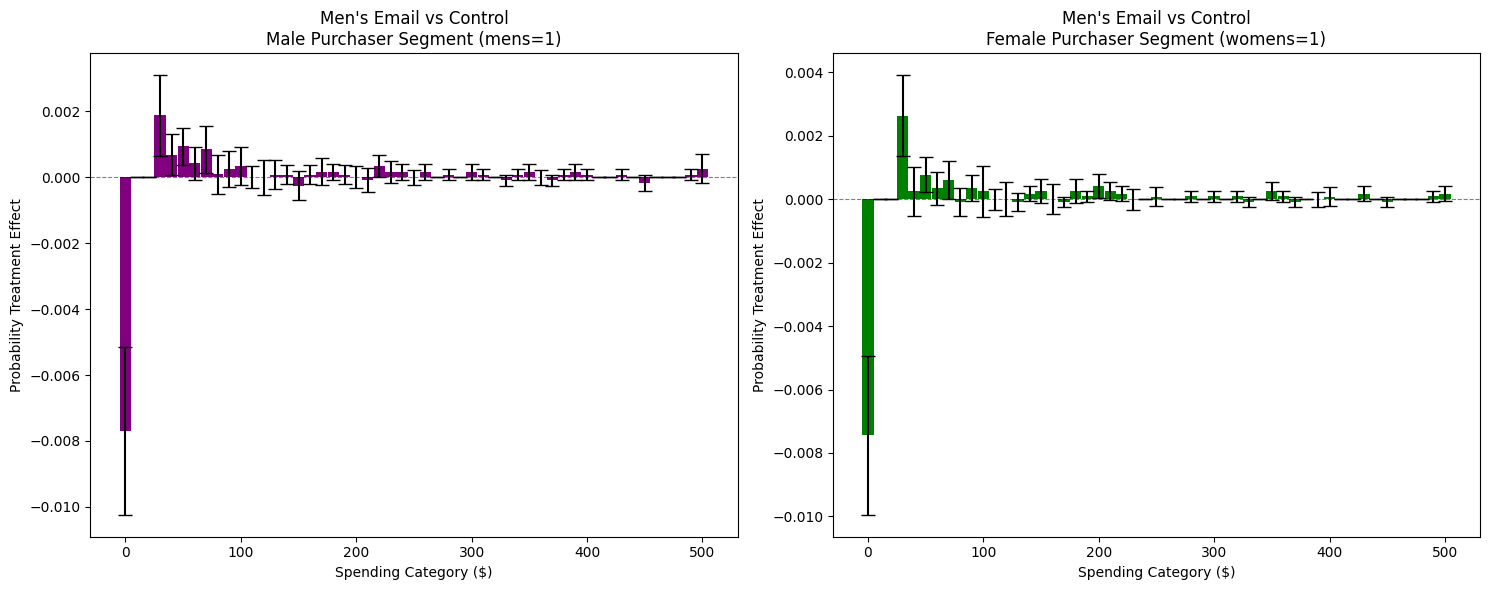


Image saved to: ../docs/source/_static/hillstorm_subgroup_men_pte.png


In [14]:
# Create 1x2 subplot for Men's Email campaign PTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Male purchaser segment PTE
plot(
    results_men_male['locations'],  # Use all locations for x-axis
    results_men_male['pte'], 
    results_men_male['pte_lower'], 
    results_men_male['pte_upper'],
    chart_type="bar",
    title="Men's Email vs Control\nMale Purchaser Segment (mens=1)",
    xlabel="Spending Category ($)", 
    ylabel="Probability Treatment Effect",
    color="purple",
    ax=ax1
)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Female purchaser segment PTE
plot(
    results_men_female['locations'],  # Use all locations for x-axis
    results_men_female['pte'], 
    results_men_female['pte_lower'], 
    results_men_female['pte_upper'],
    chart_type="bar",
    title="Men's Email vs Control\nFemale Purchaser Segment (womens=1)",
    xlabel="Spending Category ($)", 
    ylabel="Probability Treatment Effect",
    color="green",
    ax=ax2
)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('../docs/source/_static/hillstorm_subgroup_men_pte.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImage saved to: ../docs/source/_static/hillstorm_subgroup_men_pte.png")